## So lets begin with complete EDA…

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

## Load Data

In [4]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [3]:
print("Train Shape: ",train.shape)
print("Test Shape: ",test.shape)

Train Shape:  (1460, 81)
Test Shape:  (1459, 80)


In [4]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

### Train Data

In [6]:
print(train.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


<Axes: >

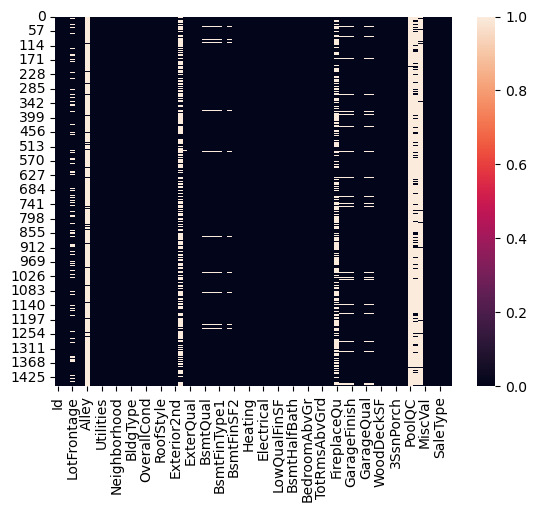

In [7]:
sns.heatmap(train.isnull())

### Test Data

In [8]:
print(test.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

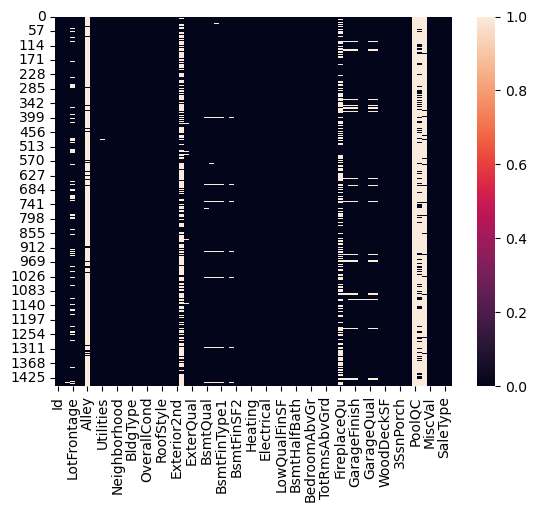

In [9]:
sns.heatmap(test.isnull())

#### For Train Data

In [5]:
cat_col_train = ['FireplaceQu','GarageType','GarageFinish','MasVnrType','BsmtQual',
           'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','FireplaceQu',
          'GarageQual','GarageCond']

ncat_col_train = ['LotFrontage','GarageYrBlt','MasVnrArea']

In [7]:
for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])
  
for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())

#### For Test Data

In [6]:
cat_col_test = ['FireplaceQu','GarageType','GarageFinish','MasVnrType','BsmtQual',
           'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','FireplaceQu',
          'GarageQual','GarageCond','MSZoning','Utilities','Exterior1st','Exterior2nd','KitchenQual','Functional','SaleType']

ncat_col_test = ['LotFrontage','GarageYrBlt','MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath',
                'BsmtHalfBath','GarageCars','GarageArea']

In [8]:
for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])
  
for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())

#### Drop Columns

In [9]:
to_drop = ['Id','Alley','PoolQC','Fence','MiscFeature']

for k in to_drop:
    train.drop([k], axis = 1, inplace = True)
    test.drop([k], axis = 1, inplace = True)

# Remove the five extreme GrLivArea observations identified during EDA.
train = train.loc[train['GrLivArea'] <= 4000].reset_index(drop=True)

<Axes: >

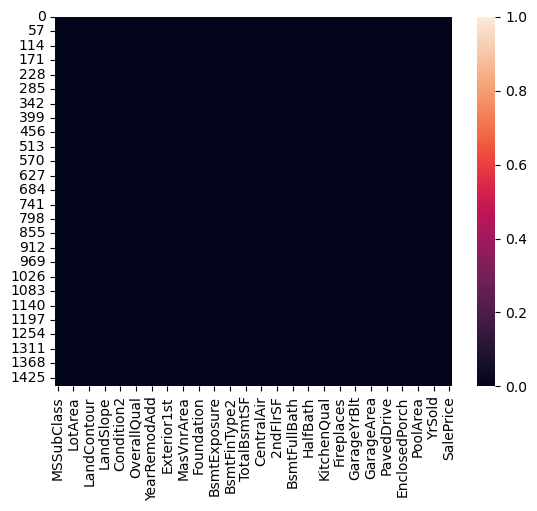

In [15]:
sns.heatmap(train.isnull())

<Axes: >

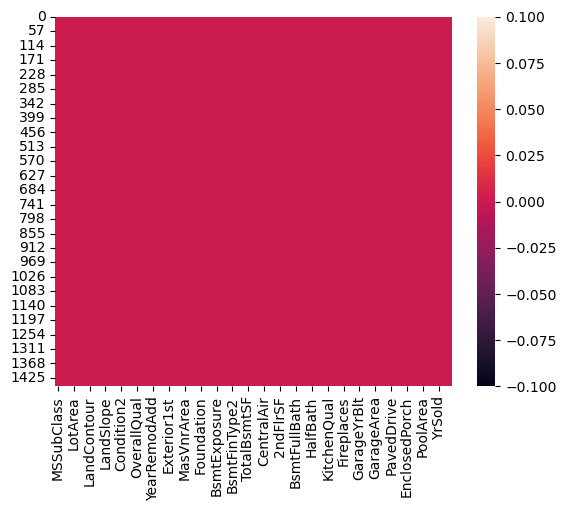

In [16]:
sns.heatmap(test.isnull())

In [17]:
print("Train Shape: ",train.shape)
print("Test Shape: ",test.shape)

Train Shape:  (1460, 76)
Test Shape:  (1459, 75)


In [10]:
final_df = pd.concat([train,test], axis = 0)
final_df.shape

(2915, 76)

In [11]:
all_cat_col = ['MSZoning','Street','LotShape','LandContour','Utilities','LotConfig','LandSlope',
              'Neighborhood','Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl',
              'Exterior1st','Exterior2nd','MasVnrType','ExterQual','ExterCond','Foundation','BsmtQual',
              'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','Heating','HeatingQC','CentralAir',
              'Electrical','KitchenQual','Functional','FireplaceQu','GarageType','GarageFinish','GarageQual',
              'GarageCond','PavedDrive','SaleType','SaleCondition']

In [12]:
def cat_onehot_encoding(multicol):
    df_final = final_df
    i = 0
    for fields in multicol:
        print(fields)
        df1 = pd.get_dummies(final_df[fields],drop_first = True)
  
        final_df.drop([fields], axis = 1, inplace = True)
        if i==0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final,df1], axis=1)
        i = i+1
  
    df_final = pd.concat([final_df,df_final], axis = 1)
  
    return df_final

In [13]:
final_df = cat_onehot_encoding(all_cat_col)

MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition


In [22]:
final_df.shape

(2919, 236)

In [14]:
final_df = final_df.loc[:,~final_df.columns.duplicated()]
final_df.shape

(2915, 175)

Let's now divide our data to train and test data.

In [15]:
df_train = final_df.iloc[:len(train), :].copy()
df_test = final_df.iloc[len(train):, :].copy()

In [16]:
df_test.drop(['SalePrice'], axis = 1, inplace = True)

In [26]:
print("Train Shape: ",df_train.shape)
print("Test Shape: ",df_test.shape)

Train Shape:  (1460, 176)
Test Shape:  (1459, 175)


## Training Data

In [17]:
x_train = df_train.drop(['SalePrice'], axis = 1)
y_train = df_train['SalePrice']

## XGBoost

In [17]:
import xgboost

xgb_model = xgboost.XGBRegressor()
xgb_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [18]:
param = {
    'n_estimators': [100, 500, 900, 1100, 1500],
    'max_depth': [2,3,5,10,15],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'min_child_weight': [1,2,3,4],
    'booster': ['gbtree','gblinear'],
    'base_score': [0.25, 0.5, 0.75, 1]
}

In [19]:
from sklearn.model_selection import RandomizedSearchCV

In [20]:
random_cv = RandomizedSearchCV(estimator=xgb_model,
                              param_distributions = param,
                              cv=5, n_iter=10,
                              scoring = 'neg_mean_absolute_error', n_jobs = 2,
                              verbose = 1,
                              return_train_score = True,
                              random_state = 42)
random_cv.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'base_score': [0.25, 0.5, ...], 'booster': ['gbtree', 'gblinear'], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [2, 3, ...], ...}"
,n_iter,10
,scoring,'neg_mean_absolute_error'
,n_jobs,2
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [32]:
random_cv.best_estimator_

,objective,'reg:squarederror'
,base_score,1
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [21]:
xgb_model = random_cv.best_estimator_
xgb_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,0.75
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


#### Save Model

In [23]:
f = "xgb_model.pkl"
pickle.dump(xgb_model,open(f,'wb'))

#### Predictions

In [24]:
pred_xgb = xgb_model.predict(df_test)
print(pred_xgb.shape)

(1459,)


#### Submission

In [26]:
sub_df = pd.read_csv('data/sample_submission.csv')
sub_df['SalePrice'] = pred_xgb
sub_df.to_csv('sample_sub_xgb.csv', index = False)

## Decision Tree

In [16]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


#### Predictions

In [25]:
pred_dt = dt_model.predict(df_test)
print(pred_dt.shape)

(1459,)


#### Submissions

In [27]:
sub_df = pd.read_csv('data/sample_submission.csv')
sub_df['SalePrice'] = pred_dt
sub_df.to_csv('sample_sub_dt.csv', index = False)

## Artificial Neural Network

In [28]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout

In [29]:
from keras import ops
def root_mean_squared_error(y_true, y_pred):
    return ops.sqrt(ops.mean(ops.square(y_pred - y_true)))

#### Model

In [30]:
nn_model = Sequential()

nn_model.add(Dense(50, kernel_initializer = 'he_uniform', activation = 'relu', input_dim = x_train.shape[1]))
nn_model.add(Dense(25, kernel_initializer = 'he_uniform', activation = 'relu'))
nn_model.add(Dense(50, kernel_initializer = 'he_uniform', activation = 'relu'))
nn_model.add(Dense(1, kernel_initializer = 'he_uniform'))

nn_model.compile(loss = root_mean_squared_error, optimizer = 'Adamax')

nn_model.fit(x_train.astype('float32').values, y_train.astype('float32').values, validation_split = 0.25, batch_size = 10, epochs = 1000)

C:\Users\Manh Dung\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 188590.1875 - val_loss: 174377.5781
Epoch 2/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 151899.4219 - val_loss: 98071.5391
Epoch 3/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 71545.2109 - val_loss: 54490.2852
Epoch 4/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 62341.7227 - val_loss: 53492.5703
Epoch 5/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 61190.3828 - val_loss: 52501.8086
Epoch 6/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 59757.2930 - val_loss: 51642.2812
Epoch 7/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 58178.6797 - val_loss: 50543.1641
Epoch 8/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 56545.0625 - val_loss: 49551.3008
Epoch 9/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 54768.6328 - val_loss: 48558.0234
Epoch 10/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 53652.4375 - val_loss: 47631.2188
Epoch 11/1000
110/110 ━━━━━━━━━━

In [31]:
nn_model.save('nn_model.h5')

#### Predictions

In [32]:
pred_nn = nn_model.predict(df_test.astype('float32').values)
print(pred_nn.shape)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
(1459, 1)


#### Submission

In [34]:
sub_df = pd.read_csv('data/sample_submission.csv')
sub_df['SalePrice'] = pred_nn.ravel()
sub_df.to_csv('sample_sub_nn.csv', index = False)

print('Submission checks:')
for file_name in ['sample_sub_xgb.csv', 'sample_sub_dt.csv', 'sample_sub_nn.csv']:
    submission = pd.read_csv(file_name)
    print(file_name, submission.shape, list(submission.columns), int(submission.isna().sum().sum()))

Submission checks:
sample_sub_xgb.csv (1459, 2) ['Id', 'SalePrice'] 0
sample_sub_dt.csv (1459, 2) ['Id', 'SalePrice'] 0
sample_sub_nn.csv (1459, 2) ['Id', 'SalePrice'] 0


## Validation, model check and final report

        Model          MAE          MSE         RMSE       R2
      XGBoost 14748.044641 5.014588e+08 22393.274739 0.904455
Decision Tree 26618.544521 1.650636e+09 40628.015910 0.685498

Model check - actual: 184000.00, predicted: 183678.27


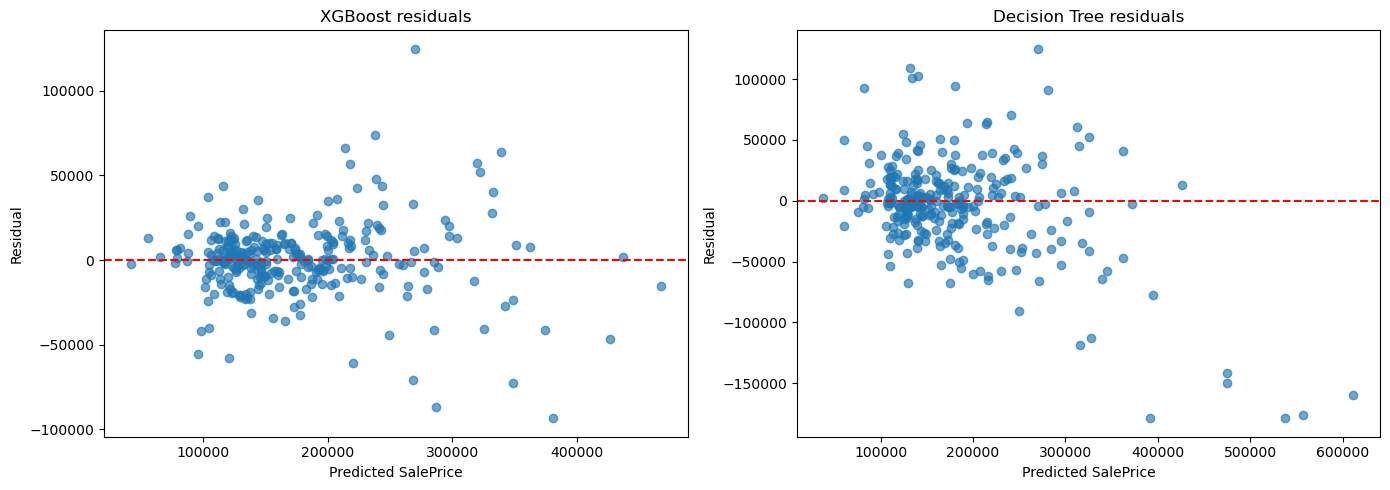

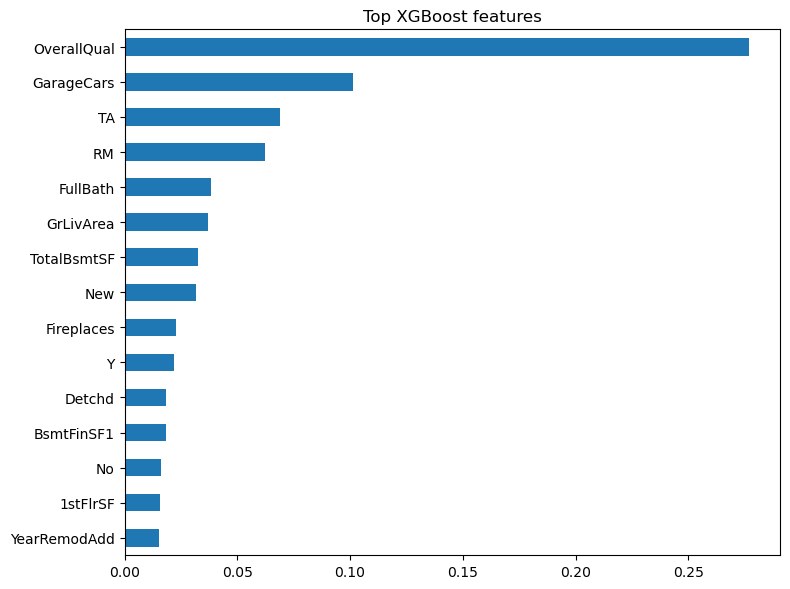

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

x_fit, x_valid, y_fit, y_valid = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

validation_models = {
    'XGBoost': xgboost.XGBRegressor(**xgb_model.get_params()),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

validation_predictions = {}
for name, model in validation_models.items():
    model.fit(x_fit, y_fit)
    validation_predictions[name] = model.predict(x_valid)

metrics = []
for name, prediction in validation_predictions.items():
    metrics.append({
        'Model': name,
        'MAE': mean_absolute_error(y_valid, prediction),
        'MSE': mean_squared_error(y_valid, prediction),
        'RMSE': mean_squared_error(y_valid, prediction) ** 0.5,
        'R2': r2_score(y_valid, prediction)
    })

metrics_df = pd.DataFrame(metrics).sort_values('RMSE')
print(metrics_df.to_string(index=False))

first_prediction = validation_predictions['XGBoost'][0]
print(f'\nModel check - actual: {y_valid.iloc[0]:.2f}, predicted: {first_prediction:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, (name, prediction) in zip(axes, validation_predictions.items()):
    residuals = y_valid.to_numpy() - prediction
    axis.scatter(prediction, residuals, alpha=0.65)
    axis.axhline(0, color='red', linestyle='--')
    axis.set_title(f'{name} residuals')
    axis.set_xlabel('Predicted SalePrice')
    axis.set_ylabel('Residual')
plt.tight_layout()
plt.show()

feature_importance = pd.Series(
    xgb_model.feature_importances_, index=x_train.columns
).sort_values(ascending=False).head(15)
feature_importance.sort_values().plot(kind='barh', figsize=(8, 6), title='Top XGBoost features')
plt.tight_layout()
plt.show()

In [2]:
%pip install pypdf
from pypdf import PdfReader
reader = PdfReader('decock.pdf')
pdf_text = '\n'.join(page.extract_text() or '' for page in reader.pages)
print('decock.pdf loaded:', len(reader.pages), 'pages')

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


incorrect startxref pointer(2)
parsing for Object Streams


Journal of Statistics Education, Volume 19, Number 3(2011) 
 1 
 
 
Ames, Iowa: Alternative to the Boston Housing Data as an 
End of Semester Regression Project 
 
Dean De Cock  
Truman State University 
 
Journal of Statistics Education Volume 19, Number 3(2011), 
www.amstat.org/publications/jse/v19n3/decock.pdf 
 
Copyright © 2011 by Dean De Cock all rights reserved. This text may be freely shared among 
individuals, but it may not be republished in any medium without express written consent from 
the author and advance notification of the editor. 
 
 
Key Words:  Multiple Regression; Linear Models; Assessed Value; Group Project. 
 
Abstract 
 
This paper presents a data set describing the sale of individual residential property in Ames, Iowa 
from 2006 to 2010. The data set contains 2930 observations and a large number of explanatory 
variables (23 nominal, 23 ordinal, 14 discrete, and 20 continuous) involved in assessing home 
values. I will discuss my previous use of the Boston Ho

In [18]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [20]:
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

xgb_model = pickle.load(open('xgb_model.pkl', 'rb'))
x_fit, x_valid, y_fit, y_valid = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)
validation_xgb = xgboost.XGBRegressor(**xgb_model.get_params())
validation_dt = DecisionTreeRegressor(random_state=42)
validation_xgb.fit(x_fit, y_fit)
validation_dt.fit(x_fit, y_fit)
validation_predictions = {
    'XGBoost': validation_xgb.predict(x_valid),
    'Decision Tree': validation_dt.predict(x_valid)
}

MODEL1 formula: SalePrice ~ OverallQual + GrLivArea + GarageCars + TotalBsmtSF + YearBuilt + FullBath
                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     1055.
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:58:04   Log-Likelihood:                -17218.
No. Observations:                1456   AIC:                         3.445e+04
Df Residuals:                    1449   BIC:                         3.449e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

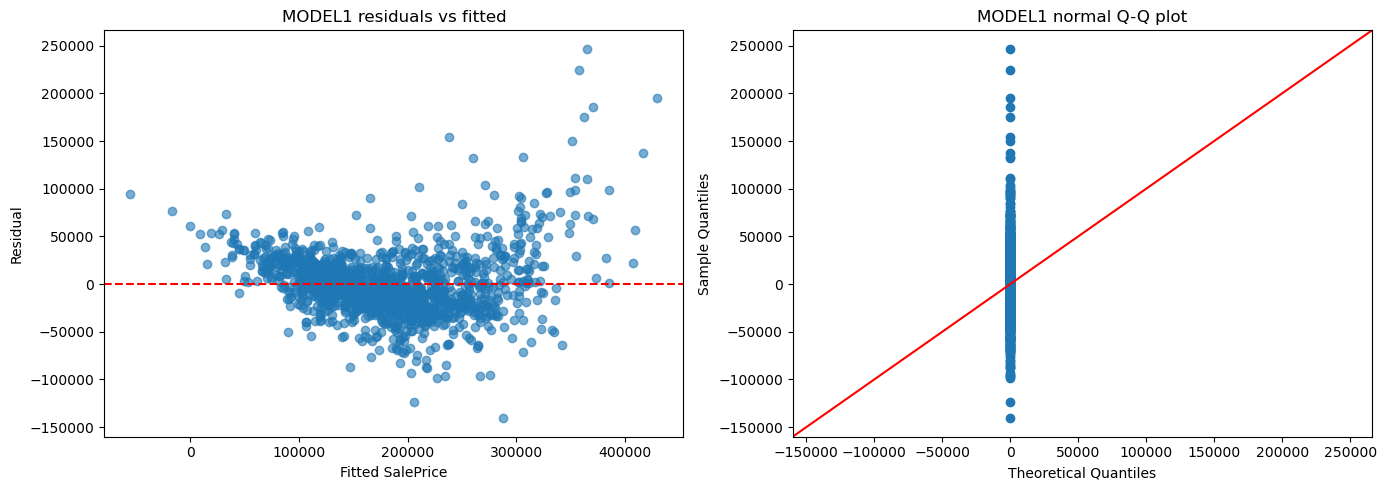

MODEL2 validation metrics from decock.pdf:
               Bias (mean predicted - actual)  Maximum Deviation  Mean Absolute Deviation  Mean Square Error
Model                                                                                                       
XGBoost                               -195.12         124,862.56                14,748.04     501,458,753.54
Decision Tree                        4,008.37         178,900.00                26,618.54   1,650,635,676.76


In [21]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

# MODEL1: interpretable linear regression with six original variables and no interactions.
model1_features = [
    'OverallQual', 'GrLivArea', 'GarageCars',
    'TotalBsmtSF', 'YearBuilt', 'FullBath'
]
model1_data = train[model1_features + ['SalePrice']].dropna().copy()
model1_x = sm.add_constant(model1_data[model1_features])
model1_y = model1_data['SalePrice']
model1 = sm.OLS(model1_y, model1_x).fit()

print('MODEL1 formula: SalePrice ~ OverallQual + GrLivArea + GarageCars + TotalBsmtSF + YearBuilt + FullBath')
print(model1.summary())
print(f'MODEL1 R-squared: {model1.rsquared:.4f}')
print(f'MODEL1 adjusted R-squared: {model1.rsquared_adj:.4f}')

# Explicit equation with at least three significant figures per coefficient.
coefficients = model1.params
terms = [f'{coefficients.iloc[0]:.6g}']
for feature in model1_features:
    terms.append(f'{coefficients[feature]:+.6g}*{feature}')
print('MODEL1 equation: SalePrice = ' + ' '.join(terms))

# Model check for the first cleaned observation, including the hand-calculation terms.
first_row = model1_data.iloc[0]
first_terms = [coefficients['const']]
for feature in model1_features:
    first_terms.append(coefficients[feature] * first_row[feature])
first_manual_prediction = sum(first_terms)
first_model_prediction = model1.predict(sm.add_constant(first_row[model1_features].to_frame().T, has_constant='add')).iloc[0]
first_actual = first_row['SalePrice']
print(f'MODEL1 first-observation check: actual=${first_actual:,.2f}, manual=${first_manual_prediction:,.2f}, statsmodels=${first_model_prediction:,.2f}, error=${first_manual_prediction - first_actual:,.2f}')

# MODEL1 assumption checks: residuals versus fitted values and a normal Q-Q plot.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(model1.fittedvalues, model1.resid, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('MODEL1 residuals vs fitted')
axes[0].set_xlabel('Fitted SalePrice')
axes[0].set_ylabel('Residual')
sm.qqplot(model1.resid, line='45', ax=axes[1])
axes[1].set_title('MODEL1 normal Q-Q plot')
plt.tight_layout()
plt.show()

# MODEL2 evaluation using De Cock's four validation measures.
def decock_metrics(actual, predicted):
    errors = predicted - actual
    return {
        'Bias (mean predicted - actual)': errors.mean(),
        'Maximum Deviation': np.abs(errors).max(),
        'Mean Absolute Deviation': np.abs(errors).mean(),
        'Mean Square Error': (errors ** 2).mean()
    }

model2_results = []
for name, prediction in validation_predictions.items():
    result = {'Model': name}
    result.update(decock_metrics(y_valid.to_numpy(), prediction))
    model2_results.append(result)
model2_metrics = pd.DataFrame(model2_results).set_index('Model')
print('MODEL2 validation metrics from decock.pdf:')
print(model2_metrics.to_string(float_format=lambda value: f'{value:,.2f}'))